In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

nav_path = project_root / "data" / "raw" / "02_nav_history.csv"

print(nav_path)

nav_df = pd.read_csv(nav_path)

nav_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\02_nav_history.csv


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


# 1

In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code','date'])
nav_df.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [4]:
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav_df['daily_return'] = nav_df['daily_return'].fillna(0)
nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


# 2

In [6]:
cagr_data = []

for fund in nav_df['amfi_code'].unique():

    fund_df = nav_df[nav_df['amfi_code'] == fund]

    latest_date = fund_df['date'].max()
    latest_nav = fund_df.iloc[-1]['nav']

    row = {'amfi_code': fund}

    for years in [1, 3, 5]:

        old_date = latest_date - pd.DateOffset(years=years)

        old_data = fund_df[fund_df['date'] <= old_date]

        if len(old_data) > 0:

            old_nav = old_data.iloc[-1]['nav']

            cagr = ((latest_nav / old_nav) ** (1 / years) - 1) * 100

            row[f'{years}Y_CAGR'] = round(cagr, 2)

        else:
            row[f'{years}Y_CAGR'] = np.nan

    cagr_data.append(row)

cagr_df = pd.DataFrame(cagr_data)

cagr_df.to_csv("cagr_report.csv", index=False)

In [7]:
cagr_df.head()

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN


In [8]:
cagr_df.shape

(40, 4)

# 3

In [9]:
sharpe_data = []

In [10]:
for fund in nav_df['amfi_code'].unique():

    fund_df = nav_df[nav_df['amfi_code'] == fund]

    avg_return = fund_df['daily_return'].mean()

    std_return = fund_df['daily_return'].std()

    risk_free_daily = 0.065 / 252

    sharpe = ((avg_return - risk_free_daily) / std_return) * np.sqrt(252)

    sharpe_data.append([fund, sharpe])

In [11]:
sharpe_df = pd.DataFrame(sharpe_data,columns=['amfi_code', 'sharpe_ratio'])
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201818
1,100025,-0.568295
2,100033,1.092921
3,101206,1.026375
4,101207,0.162371


In [12]:
sharpe_df.shape

(40, 2)

# 4

In [13]:
sortino_data = []

In [14]:
for fund in nav_df['amfi_code'].unique():

    fund_df = nav_df[nav_df['amfi_code'] == fund]

    avg_return = fund_df['daily_return'].mean()

    negative_returns = fund_df[fund_df['daily_return'] < 0]['daily_return']

    downside_std = negative_returns.std()

    risk_free_daily = 0.065 / 252

    sortino = ((avg_return - risk_free_daily) / downside_std) * np.sqrt(252)

    sortino_data.append([fund, sortino])

In [15]:
sortino_df = pd.DataFrame(sortino_data, columns=['amfi_code', 'sortino_ratio'])
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351419
1,100025,-0.943406
2,100033,1.827044
3,101206,1.797318
4,101207,0.276031


In [16]:
sortino_df.shape

(40, 2)

# 5

In [17]:
from scipy.stats import linregress

In [18]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

bench_path = project_root / "data" / "raw" / "10_benchmark_indices.csv"

print(bench_path)

benchmark_df = pd.read_csv(bench_path)

benchmark_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\10_benchmark_indices.csv


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [19]:
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'], format='mixed')

In [20]:
nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [21]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (nifty100['close_value'].pct_change())
nifty100 = nifty100[['date','benchmark_return']]
nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [22]:
nifty100.shape

(1150, 2)

In [24]:
from scipy.stats import linregress
import pandas as pd

result = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[nav_df['amfi_code'] == fund]

    merged = pd.merge(temp, nifty100, on='date', how='inner').dropna(subset=['daily_return', 'benchmark_return'])

    if len(merged) > 1:

        slope, intercept, _, _, _ = linregress(merged['benchmark_return'],merged['daily_return'])

        result.append({'amfi_code': fund, 'alpha': intercept * 252, 'beta': slope})

In [25]:
alpha_beta_df = pd.DataFrame(result,columns=['amfi_code','alpha','beta'])
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [26]:
alpha_beta_df.shape

(40, 3)

In [27]:
from IPython.display import FileLink

alpha_beta_df.to_csv("alpha_beta.csv", index=False)

FileLink("alpha_beta.csv")

C:\Users\Shruti Singhania\alpha_beta.csv

# 6

In [28]:
result = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[nav_df['amfi_code']==fund].sort_values('date')

    running_max = temp['nav'].cummax()

    drawdown = (temp['nav']/running_max) - 1

    max_dd = drawdown.min()

    worst_date = temp.loc[drawdown.idxmin(),'date']

    result.append([fund, max_dd*100, worst_date])

In [29]:
mdd_df = pd.DataFrame(result, columns=['amfi_code','max_drawdown_percent','worst_date'])
mdd_df.head()

,amfi_code,max_drawdown_percent,worst_date
0,100016,-24.734441,2022-09-15
1,100025,-4.308264,2023-07-28
2,100033,-16.217209,2022-05-12
3,101206,-11.291596,2023-07-05
4,101207,-35.446916,2026-05-11


In [30]:
mdd_df.shape

(40, 3)

# 7

In [31]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

fund_path = project_root / "data" / "raw" / "01_fund_master.csv"

print(fund_path)

expense_df = pd.read_csv(fund_path)

expense_df = pd.DataFrame(expense_df, columns=['amfi_code', 'expense_ratio_pct'])
expense_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\01_fund_master.csv


,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [32]:
expense_df.shape

(40, 2)

In [33]:
scorecard = (cagr_df.merge(sharpe_df,on='amfi_code').merge(alpha_beta_df,on='amfi_code').merge(expense_df,on='amfi_code').merge(mdd_df,on='amfi_code'))

scorecard['return_rank'] = scorecard['3Y_CAGR'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank()
scorecard['dd_rank'] = scorecard['max_drawdown_percent'].rank()

scorecard['fund_score'] = (
    0.30*scorecard['return_rank'] +
    0.25*scorecard['sharpe_rank'] +
    0.20*scorecard['alpha_rank'] +
    0.15*scorecard['expense_rank'] +
    0.10*scorecard['dd_rank']
)

scorecard['fund_score'] = (100 -(scorecard['fund_score']/scorecard['fund_score'].max()*100))

In [42]:
scorecard.head()

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR,sharpe_ratio,alpha,beta,expense_ratio_pct,max_drawdown_percent,worst_date,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
0,100016,-2.22,1.29,NaN,-0.201818,0.037476,-0.058268,1.55,-24.734441,2022-09-15,35.0,35.0,39.0,32.0,7.0,1.587302
1,100025,3.70,3.92,NaN,-0.568295,0.042818,0.001158,0.56,-4.308264,2023-07-28,34.0,39.0,38.0,2.0,37.0,4.610733
2,100033,53.23,32.44,NaN,1.092921,0.271954,0.005104,1.38,-16.217209,2022-05-12,4.0,7.0,6.0,17.0,21.0,73.393802
3,101206,47.92,28.97,NaN,1.026375,0.213998,0.021086,1.60,-11.291596,2023-07-05,9.0,9.0,12.0,36.5,32.0,51.549509
4,101207,-23.99,-4.15,NaN,0.162371,0.108971,-0.065289,1.53,-35.446916,2026-05-11,39.0,28.0,27.0,28.5,3.0,13.303099


In [43]:
from IPython.display import FileLink

scorecard.to_csv("fund_scorecard.csv", index=False)

FileLink("fund_scorecard.csv")

C:\Users\Shruti Singhania\fund_scorecard.csv

# 8

In [36]:
nifty50 = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()

nifty50 = nifty50.sort_values('date')

In [37]:
nifty50['benchmark_return'] = (nifty50['close_value'].pct_change())
nifty100['benchmark_return'] = (nifty100['benchmark_return'])

In [38]:
top5 = scorecard.sort_values('fund_score',ascending=False).head(5)['amfi_code']

In [39]:
tracking = []

for fund in top5:

    temp = fund_df[fund_df['amfi_code'] == fund]

    merged = pd.merge(temp,nifty100,on='date')

    merged = merged.dropna()

    tracking_error = ((merged['daily_return']-merged['benchmark_return']).std()) * np.sqrt(252)

    tracking.append([fund,tracking_error])

In [40]:
tracking_df = pd.DataFrame(tracking,columns=['amfi_code','tracking_error'])
tracking_df.head()

,amfi_code,tracking_error
0,120505,NaN
1,119094,NaN
2,100033,NaN
3,148567,NaN
4,120843,NaN


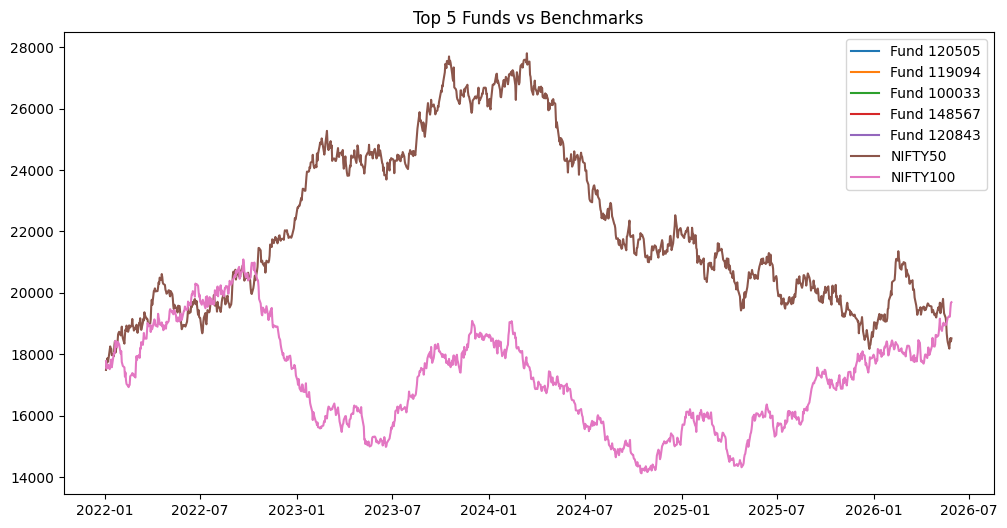

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top5:

    temp = fund_df[fund_df['amfi_code'] == fund]

    plt.plot(pd.to_datetime(temp['date']), temp['nav'], label=f"Fund {fund}")

plt.plot(nifty50['date'], nifty50['close_value'], label='NIFTY50')

plt.plot(benchmark_df[benchmark_df['index_name']=='NIFTY100']['date'],
         benchmark_df[benchmark_df['index_name']=='NIFTY100']['close_value'],
         label='NIFTY100')

plt.title("Top 5 Funds vs Benchmarks")
plt.legend()
plt.show()